In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Load the Telco Customer Churn dataset
data = pd.read_csv('Telco-Customer-Churn.csv')

# Quick look at the data
print(data.head())
print(data.info())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
data = data.drop('customerID', axis=1)

# Convert TotalCharges to numeric, coerce errors to NaN
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with median
data['TotalCharges']=data['TotalCharges'].fillna(data['TotalCharges'].median())

# Encode target variable 'Churn'
data['Churn'] = data['Churn'].map({'Yes':1, 'No':0})

# Encode categorical variables using LabelEncoder
cat_cols = data.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

# Scale numeric features for neural network
num_cols = ['tenure','MonthlyCharges','TotalCharges']
scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])


In [4]:
# Features and target
X = data.drop('Churn', axis=1)
y = data['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("x_train.shape:" ,X_train.shape)
print("y_train.shape:" ,y_train.shape)
print("x_test.shape:" ,X_test.shape)
print("y_test.shape:" ,y_test.shape)


x_train.shape: (5634, 19)
y_train.shape: (5634,)
x_test.shape: (1409, 19)
y_test.shape: (1409,)


In [5]:
#    Decision Tree
clf = DecisionTreeClassifier(
    random_state=0,
    criterion='entropy',
    ccp_alpha=0.001,
    max_depth=10,
    min_samples_leaf=4,
    min_samples_split=20,
    splitter='random'
)


clf.fit(X_train, y_train)

dtc_y_pred_prob = clf.predict_proba(X_test)[:, 1]

auccuracy_dtc = roc_auc_score(y_test, dtc_y_pred_prob)
print("ROC-AUC Score - DTC :", auccuracy_dtc)

ROC-AUC Score - DTC : 0.8250045209124492


In [6]:
#   NN model
nn_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(19,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [7]:
nn_model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)#prevent overfitting

In [8]:
#training the model
history = nn_model.fit(
X_train, y_train,
validation_split=0.2,
epochs=30,
batch_size=16,
verbose=0
)

nn_y_pred_prob = nn_model.predict(X_test).ravel()

auccuracy_nn = roc_auc_score(y_test, nn_y_pred_prob)
print("ROC-AUC Score - NN :", auccuracy_nn)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
ROC-AUC Score - NN : 0.8359812963393526


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step


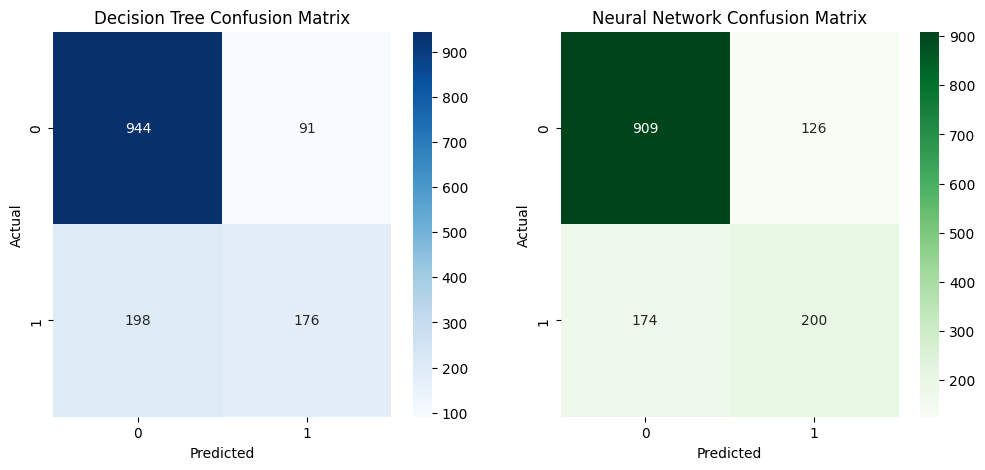

In [10]:
y_pred_dtc = clf.predict(X_test)
y_pred_nn = nn_model.predict(X_test)

# If your NN outputs probabilities, convert to class labels
# Example: assuming binary classification with threshold 0.5
import numpy as np
if y_pred_nn.ndim > 1 and y_pred_nn.shape[1] == 1:  # single output neuron
    y_pred_nn = (y_pred_nn > 0.5).astype(int)
elif y_pred_nn.ndim > 1 and y_pred_nn.shape[1] > 1:  # softmax
    y_pred_nn = np.argmax(y_pred_nn, axis=1)

# 2. Confusion matrices
cm_dtc = confusion_matrix(y_test, y_pred_dtc)
cm_nn = confusion_matrix(y_test, y_pred_nn)

# 3. Plot confusion matrices using seaborn
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(cm_dtc, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1,2,2)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Greens')
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [11]:
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dtc))
print("Neural Network Classification Report:\n", classification_report(y_test, y_pred_nn))

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.66      0.47      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Neural Network Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.61      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.71      1409
weighted avg       0.78      0.79      0.78      1409



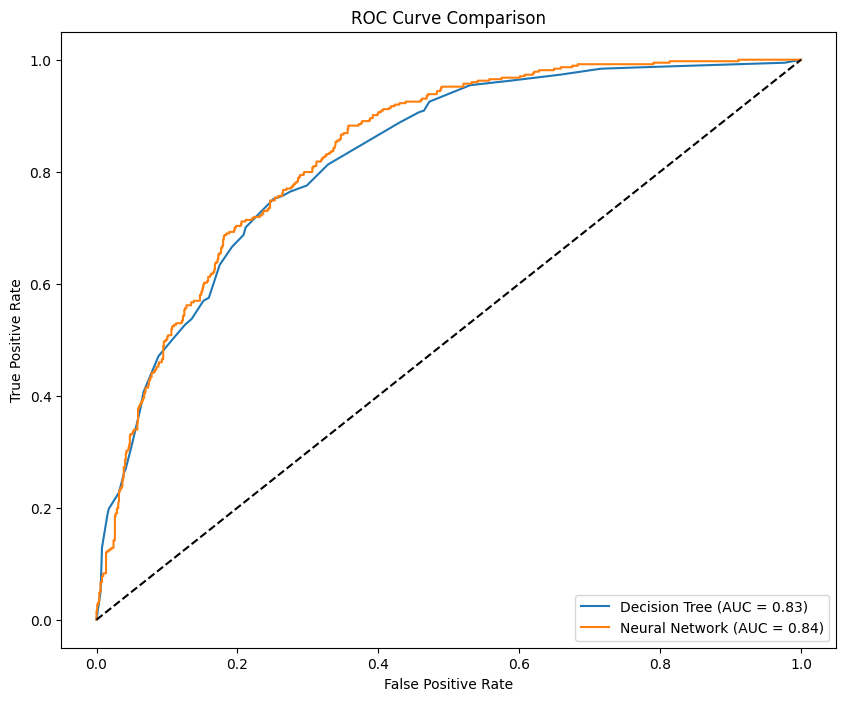

In [ ]:

fpr_dtc, tpr_dtc, _ = roc_curve(y_test, dtc_y_pred_prob)
auc_dtc = auc(fpr_dtc, tpr_dtc)

fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_y_pred_prob)
auc_nn = auc(fpr_nn, tpr_nn)

# Plot ROC curves
plt.figure(figsize=(10,8))
plt.plot(fpr_dtc, tpr_dtc, label=f'Decision Tree (AUC = {auc_dtc:.2f})')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.2f})')
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()